In [37]:
import numpy as np
import matplotlib.pyplot as plt
steps = 1000000
positions = np.zeros((steps, 3, 2))
velocities = np.zeros((steps, 3, 2))
TotEnergyErrors = np.zeros((steps,1))
h = 0.001
G =  1.5
Mass1 = 10
Mass2 = 10
Mass3 = 10
r1i = np.array([25, 1 ])
r2i = np.array( [0, 2])
r3i = np.array([-30, 3])
v1i = np.array([0,  0.3])
v2i = np.array([0,  -0.5])
v3i = np.array([0.5, 0.6])
Eki = (0.5*Mass1*np.linalg.norm(v1i)**2)+(0.5*Mass2*np.linalg.norm(v2i)**2)+(0.5*Mass3*np.linalg.norm(v3i)**2)
Epi = -G*(((Mass1*Mass2)/np.linalg.norm(r2i - r1i))+((Mass1*Mass3)/np.linalg.norm(r3i - r1i))+((Mass2*Mass3)/np.linalg.norm(r3i - r2i)))
Etoti = Eki + Epi
print ("initial total energy = ", Etoti)
Ac1i = ((G*Mass2)*(r2i-r1i)/np.linalg.norm(r2i - r1i)**3)+((G*Mass3)*(r3i-r1i)/np.linalg.norm(r3i - r1i)**3)
Ac2i = ((G*Mass1)*(r1i-r2i)/np.linalg.norm(r1i - r2i)**3)+((G*Mass3)*(r3i-r2i)/np.linalg.norm(r3i - r2i)**3)
Ac3i = ((G*Mass1)*(r1i-r3i)/np.linalg.norm(r1i - r3i)**3)+((G*Mass2)*(r2i-r3i)/np.linalg.norm(r2i - r3i)**3)
i=0

for i in range(steps):
    r1n = r1i + v1i*h+0.5*Ac1i*h**2
    r2n = r2i + v2i*h+0.5*Ac2i*h**2
    r3n = r3i + v3i*h+0.5*Ac3i*h**2
    Ac1n = ((G*Mass2)*(r2n-r1n)/np.linalg.norm(r2n - r1n)**3)+((G*Mass3)*(r3n-r1n)/np.linalg.norm(r3n - r1n)**3)
    Ac2n = ((G*Mass1)*(r1n-r2n)/np.linalg.norm(r1n - r2n)**3)+((G*Mass3)*(r3n-r2n)/np.linalg.norm(r3n - r2n)**3)
    Ac3n = ((G*Mass1)*(r1n-r3n)/np.linalg.norm(r1n - r3n)**3)+((G*Mass2)*(r2n-r3n)/np.linalg.norm(r2n - r3n)**3)
    v1n = v1i + 0.5*h*(Ac1i +Ac1n)
    v2n = v2i + 0.5*h*(Ac2i +Ac2n)
    v3n = v3i + 0.5*h*(Ac3i +Ac3n)
    r1i = r1n
    r2i = r2n
    r3i = r3n
    v1i = v1n
    v2i = v2n
    v3i = v3n
    Ac1i = Ac1n
    Ac2i =Ac2n
    Ac3i =Ac3n
    positions[i, 0] = r1n
    positions[i, 1] = r2n
    positions[i, 2] = r3n 
    velocities[i, 0] = v1n
    velocities[i, 1] = v2n
    velocities[i, 2] = v3n 
    TotEnergyErrors[i] = Etoti - ((0.5*Mass1*np.linalg.norm(v1n)**2)+(0.5*Mass2*np.linalg.norm(v2n)**2)+(0.5*Mass3*np.linalg.norm(v3n)**2) -G*(((Mass1*Mass2)/np.linalg.norm(r2n - r1n))+((Mass1*Mass3)/np.linalg.norm(r3n - r1n))+((Mass2*Mass3)/np.linalg.norm(r3n - r2n))))
    i= i+1 


initial total energy =  -8.967901645262232


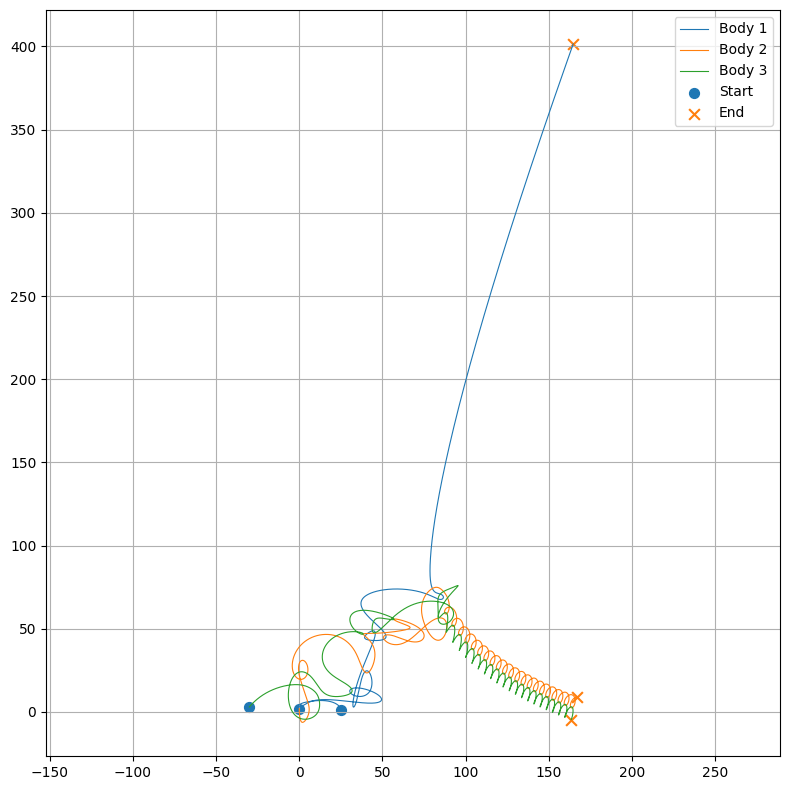

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Maximum number of points to plot
MAX_POINTS = 10000

# Choose a stride automatically
stride = max(1, len(positions) // MAX_POINTS)

# Downsample
sample = positions[::stride]

plt.figure(figsize=(8, 8))

plt.plot(sample[:, 0, 0], sample[:, 0, 1], lw=0.8, label="Body 1")
plt.plot(sample[:, 1, 0], sample[:, 1, 1], lw=0.8, label="Body 2")
plt.plot(sample[:, 2, 0], sample[:, 2, 1], lw=0.8, label="Body 3")

plt.scatter(sample[0, :, 0], sample[0, :, 1],
            marker='o', s=50, label="Start")

plt.scatter(sample[-1, :, 0], sample[-1, :, 1],
            marker='x', s=60, label="End")

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

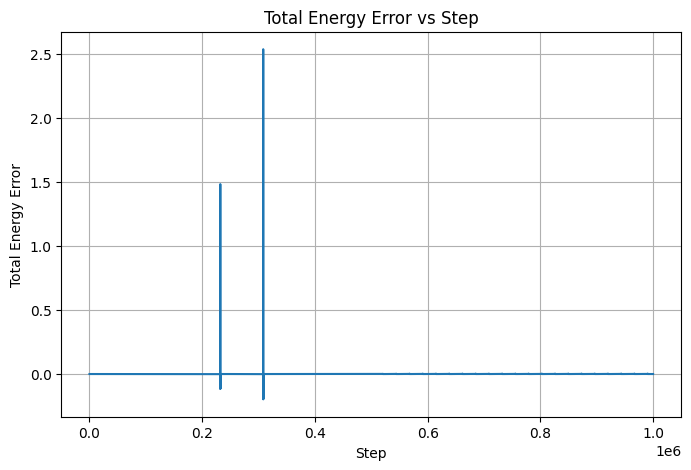

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(range(steps), TotEnergyErrors.flatten())
plt.xlabel("Step")
plt.ylabel("Total Energy Error")
plt.title("Total Energy Error vs Step")
plt.grid(True)
plt.show()

In [39]:
print("r1 =", r1n)
print("r2 =", r2n)
print("r3 =", r3n)

r1 = [164.69658444 401.59101717]
r2 = [166.85450083   8.97721479]
r3 = [163.44891473  -4.56823196]


In [33]:
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter

fig, ax = plt.subplots(figsize=(8, 8))

margin = 1
ax.set_xlim(positions[:, :, 0].min() - margin,
            positions[:, :, 0].max() + margin)
ax.set_ylim(positions[:, :, 1].min() - margin,
            positions[:, :, 1].max() + margin)
ax.set_aspect("equal")
ax.grid(True)

scatter = ax.scatter([], [], s=50)

writer = FFMpegWriter(fps=60)

LAST_STEPS = 20000
FRAME_SKIP = 20

start = max(0, len(positions) - LAST_STEPS)

with writer.saving(fig, "three_body.mp4", dpi=150):

    for i in range(start, len(positions), FRAME_SKIP):

        scatter.set_offsets(positions[i])

        writer.grab_frame()

plt.close(fig)